In [ ]:
# 1. Força a exclusão da pasta antiga para evitar conflitos se rodar de novo
!rm -rf dados_brutos

!mkdir dados_brutos
!mkdir dados_brutos/normal
!mkdir dados_brutos/imbalance
!mkdir dados_brutos/horizontal-misalignment
!mkdir dados_brutos/vertical-misalignment
!mkdir dados_brutos/overhang
!mkdir dados_brutos/underhang

print("Baixando os datasets da UFRJ...")
!wget -q -O normal.zip "https://www02.smt.ufrj.br/~offshore/mfs/database/mafaulda/normal.zip"
!wget -q -O imbalance.zip "https://www02.smt.ufrj.br/~offshore/mfs/database/mafaulda/imbalance.zip"
!wget -q -O overhang.zip "https://www02.smt.ufrj.br/~offshore/mfs/database/mafaulda/overhang.zip"
!wget -q -O underhang.zip "https://www02.smt.ufrj.br/~offshore/mfs/database/mafaulda/underhang.zip"
!wget -q -O horizontal.zip "https://www02.smt.ufrj.br/~offshore/mfs/database/mafaulda/horizontal-misalignment.zip"
!wget -q -O vertical.zip "https://www02.smt.ufrj.br/~offshore/mfs/database/mafaulda/vertical-misalignment.zip"

print("Extraindo os arquivos...")
!unzip -q -o normal.zip -d dados_brutos/normal
!unzip -q -o imbalance.zip -d dados_brutos/imbalance
!unzip -q -o overhang.zip -d dados_brutos/overhang
!unzip -q -o underhang.zip -d dados_brutos/underhang

!unzip -q -o horizontal.zip -d dados_brutos/horizontal-misalignment
!unzip -q -o vertical.zip -d dados_brutos/vertical-misalignment

print("Limpando arquivos .zip temporários...")
!rm normal.zip imbalance.zip horizontal.zip vertical.zip overhang.zip underhang.zip

print("✅ Todos os dados baixados e organizados!")

Baixando os datasets da UFRJ...
Extraindo os arquivos...
Limpando arquivos .zip temporários...
✅ Todos os dados baixados e organizados!


In [ ]:
import os
import glob
import pandas as pd
import numpy as np
from scipy.stats import kurtosis, skew
from scipy.fft import fft, fftfreq
from scipy.signal import butter, filtfilt, hilbert

TAXA_AMOSTRAGEM = 51200
# 1. AUMENTAMOS A JANELA: 51200/8192 = 6.25 Hz de resolução (Perfeito para motores!)
TAMANHO_JANELA = 8192
COLUNAS = ['tachometer', 'uh_ax', 'uh_rad', 'uh_tan', 'oh_ax', 'oh_rad', 'oh_tan', 'microphone']

dataset_processado = []

# --- FUNÇÃO 1: Bandas de Frequência Inteligentes ---
def obter_features_espectrais(yf_pos, xf_pos):
    features = {}

    # Fatiamento mais cirúrgico nas baixas frequências (onde mora Desalinhamento e Desbalanceamento)
    # E fatiamento mais largo nas altas (Rolamentos)
    limites_bandas = [
        (0, 50), (50, 100), (100, 200),
        (200, 400), (400, 800), (800, 1500),
        (1500, 3000), (3000, 5000), (5000, 10000)
    ]

    for limite_inf, limite_sup in limites_bandas:
        # Filtra apenas os pontos do eixo X que estão dentro desta gaveta
        mascara = (xf_pos >= limite_inf) & (xf_pos < limite_sup)
        nome_banda = f"b_{limite_inf}_{limite_sup}"

        if np.any(mascara):
            # O SEGREDO 1: A soma ajuda a ver o aquecimento global de atrito
            features[f'{nome_banda}_energia'] = np.sum(yf_pos[mascara])
            # O SEGREDO 2: O Max encontra a "agulha no palheiro" do rolamento quebrado
            features[f'{nome_banda}_pico'] = np.max(yf_pos[mascara])
        else:
            features[f'{nome_banda}_energia'] = 0.0
            features[f'{nome_banda}_pico'] = 0.0

    return features

# --- FUNÇÃO 2: Análise de Envelope (O Caçador de Rolamentos) ---
def extrair_picos_envelope(sinal_array):
    # 1. Filtro Passa-Alta (Remove o ruído grosso do motor, corta tudo abaixo de 2000Hz)
    nyquist = 0.5 * TAXA_AMOSTRAGEM
    corte_normalizado = 2000.0 / nyquist
    b, a = butter(4, corte_normalizado, btype='high')
    sinal_filtrado = filtfilt(b, a, sinal_array)

    # 2. Retificação e Envelope (Transformada de Hilbert)
    sinal_analitico = hilbert(sinal_filtrado)
    envelope = np.abs(sinal_analitico)

    # 3. FFT do Envelope
    yf_env = np.abs(fft(envelope))
    xf_env = fftfreq(TAMANHO_JANELA, 1 / TAXA_AMOSTRAGEM)
    yf_env_pos = yf_env[:TAMANHO_JANELA//2]
    xf_env_pos = xf_env[:TAMANHO_JANELA//2]
    yf_env_pos[0] = 0 # Remove ruído DC

    # 4. Pega os 3 maiores picos do Envelope
    indices_top = np.argsort(yf_env_pos)[-3:][::-1]
    freqs = np.round(xf_env_pos[indices_top], 2)
    amps = np.round(yf_env_pos[indices_top] / (TAMANHO_JANELA//2), 4)

    return freqs, amps

# --- FUNÇÃO PRINCIPAL ---
def mastigar_dados_god_payload(caminho_arquivo, label_defeito):
    df_bruto = pd.read_csv(caminho_arquivo, header=None, names=COLUNAS)

    for inicio in range(0, len(df_bruto) - TAMANHO_JANELA, TAMANHO_JANELA):
        janela = df_bruto.iloc[inicio : inicio + TAMANHO_JANELA]

        # 1. DOMÍNIO DO TEMPO (RMS, Kurtose e Skewness)
        rms_x = np.sqrt(np.mean(janela['oh_rad']**2))
        rms_y = np.sqrt(np.mean(janela['oh_tan']**2))
        rms_z = np.sqrt(np.mean(janela['oh_ax']**2))
        rms_global = np.sqrt(rms_x**2 + rms_y**2 + rms_z**2)

        kurt_x = kurtosis(janela['oh_rad'], fisher=False)
        kurt_y = kurtosis(janela['oh_tan'], fisher=False)
        kurt_z = kurtosis(janela['oh_ax'], fisher=False)

        skew_x = skew(janela['oh_rad'], bias=False)
        skew_y = skew(janela['oh_tan'], bias=False)
        skew_z = skew(janela['oh_ax'], bias=False)

        # 2. DOMÍNIO DA FREQUÊNCIA (Bandas de Energia e Pico)
        # CORREÇÃO 1: Chamando o nome novo da função
        yf_x = np.abs(fft(janela['oh_rad'].values))
        xf_x = fftfreq(TAMANHO_JANELA, 1 / TAXA_AMOSTRAGEM)
        bandas_x = obter_features_espectrais(yf_x[:TAMANHO_JANELA//2], xf_x[:TAMANHO_JANELA//2])

        # 3. ANÁLISE DE ENVELOPE (Foco nos Rolamentos, eixos Radial e Axial)
        env_x_freq, env_x_amp = extrair_picos_envelope(janela['oh_rad'].values)
        env_z_freq, env_z_amp = extrair_picos_envelope(janela['oh_ax'].values)

        # 4. ÁUDIO / MICROFONE
        mic_rms = np.sqrt(np.mean(janela['microphone']**2))
        mic_pico = np.max(np.abs(janela['microphone']))
        fator_crista = mic_pico / mic_rms if mic_rms > 0 else 0

        # MONTANDO A LINHA (Features blindadas)
        linha = {
            'rms_global': rms_global,
            'rms_x': rms_x, 'rms_y': rms_y, 'rms_z': rms_z,
            'kurt_x': kurt_x, 'kurt_y': kurt_y, 'kurt_z': kurt_z,
            'skew_x': skew_x, 'skew_y': skew_y, 'skew_z': skew_z,

            # CORREÇÃO 2: O Desempacotamento. Isso injeta as 18 colunas de banda aqui automaticamente!
            **bandas_x,

            # Picos de Envelope (Rolamentos)
            'env_x_f1': env_x_freq[0], 'env_x_a1': env_x_amp[0],
            'env_x_f2': env_x_freq[1], 'env_x_a2': env_x_amp[1],
            'env_z_f1': env_z_freq[0], 'env_z_a1': env_z_amp[0],
            'env_z_f2': env_z_freq[1], 'env_z_a2': env_z_amp[1],

            'piezo_rms': mic_rms,
            'piezo_crista': fator_crista,

            'label_original': label_defeito,
            'arquivo_origem': caminho_arquivo,
            'inicio_janela': inicio
        }
        dataset_processado.append(linha)

MAPA_DEFEITOS = {
    "normal": 0,
    "imbalance": 1,
    "horizontal-misalignment": 2,
    "vertical-misalignment": 3,
    "overhang/ball_fault": 4,
    "overhang/cage_fault": 5,
    "overhang/outer_race": 6,
    "underhang/ball_fault": 7,
    "underhang/cage_fault": 8,
    "underhang/outer_race": 9
}

print("Iniciando varredura com Extração Avançada (Demora um pouco mais agora)...")
caminho_base = 'dados_brutos'

for pasta_chave, label_id in MAPA_DEFEITOS.items():
    padrao_busca = os.path.join(caminho_base, '**', pasta_chave, '**', '*.csv')
    arquivos_encontrados = glob.glob(padrao_busca, recursive=True)

    if len(arquivos_encontrados) > 0:
        print(f"-> Processando {len(arquivos_encontrados)} arquivos: {pasta_chave}")
        for caminho in arquivos_encontrados:
            mastigar_dados_god_payload(caminho, label_id)

df_inteligencia = pd.DataFrame(dataset_processado)
df_inteligencia.to_csv('dataset_motor_super.csv', index=False)
print(f"\n✅ Concluído! Extraídas {len(df_inteligencia)} amostras com {len(df_inteligencia.columns)} colunas.")

Iniciando varredura com Extração Avançada (Demora um pouco mais agora)...
-> Processando 98 arquivos: normal
-> Processando 666 arquivos: imbalance
-> Processando 394 arquivos: horizontal-misalignment
-> Processando 602 arquivos: vertical-misalignment
-> Processando 137 arquivos: overhang/ball_fault
-> Processando 188 arquivos: overhang/cage_fault
-> Processando 188 arquivos: overhang/outer_race
-> Processando 186 arquivos: underhang/ball_fault
-> Processando 188 arquivos: underhang/cage_fault
-> Processando 184 arquivos: underhang/outer_race

✅ Concluído! Extraídas 84930 amostras com 41 colunas.


In [ ]:
# Salva a tabela extraída (que tem poucos Megabytes) em um CSV
from google.colab import files
files.download('dataset_motor_super.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import librosa
import matplotlib.pyplot as plt
import shutil

print("1. Faxina: Removendo os ZIPs viciados do Google Drive...")
pasta_destino_drive = '/content/drive/MyDrive/Dataset_Metrologia_Multimodal'
zips_antigos = glob.glob(os.path.join(pasta_destino_drive, '*.zip'))
for z in zips_antigos:
    os.remove(z)
print("✅ Limpeza concluída.")

print("\n2. Carregando o Dataset Bruto e Aplicando Embaralhamento Global...")
# Carrega o CSV raiz (antes das imagens)
df_completo = pd.read_csv('dataset_motor_super.csv')

# --- O SEGREDO DO SUCESSO: O SHUFFLE ---
df_completo = df_completo.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"✅ {len(df_completo)} linhas embaralhadas perfeitamente.")

# --- CONFIGURAÇÕES ---
TAMANHO_DO_LOTE = 20000
TAXA_AMOSTRAGEM = 51200
TAMANHO_JANELA = 8192
pasta_temp = '/content/temp_imagens'

if 'caminho_imagem' not in df_completo.columns:
    df_completo['caminho_imagem'] = ""

print("\n3. Iniciando a Geração Fatiada dos Espectrogramas (Agora misturados!)...")

total_amostras = len(df_completo)
for inicio_lote in range(0, total_amostras, TAMANHO_DO_LOTE):
    fim_lote = min(inicio_lote + TAMANHO_DO_LOTE, total_amostras)
    df_lote = df_completo.iloc[inicio_lote:fim_lote].copy()

    numero_lote = (inicio_lote // TAMANHO_DO_LOTE) + 1
    nome_zip = f'espectrogramas_embaralhados_lote_{numero_lote:03d}'
    caminho_zip_final = os.path.join(pasta_destino_drive, nome_zip + '.zip')

    print(f"\n--- Criando Lote Misto {numero_lote} (Linhas {inicio_lote} a {fim_lote}) ---")

    if os.path.exists(pasta_temp):
        shutil.rmtree(pasta_temp)
    os.makedirs(pasta_temp)

    for index, row in df_lote.iterrows():
        caminho_csv_bruto = row['arquivo_origem']
        label = row['label_original']
        inicio_janela = int(row['inicio_janela'])

        pasta_classe = os.path.join(pasta_temp, f'classe_{label}')
        os.makedirs(pasta_classe, exist_ok=True)

        # Pega o índice global do dataframe para o nome ser único
        indice_real = df_lote.index.get_loc(index) + inicio_lote
        nome_imagem = f'img_{indice_real:07d}.png'
        caminho_imagem = os.path.join(pasta_classe, nome_imagem)

        try:
            df_bruto = pd.read_csv(caminho_csv_bruto, header=None, nrows=TAMANHO_JANELA)
            sinal_radial = df_bruto.iloc[:, 2].values

            espectrograma = librosa.feature.melspectrogram(
                y=sinal_radial, sr=TAXA_AMOSTRAGEM, n_fft=TAMANHO_JANELA, hop_length=256, n_mels=64
            )
            imagem_db = librosa.power_to_db(espectrograma, ref=np.max)

            plt.imsave(caminho_imagem, imagem_db, cmap='viridis')
            df_completo.at[index, 'caminho_imagem'] = caminho_imagem

        except Exception as e:
            pass

        if (indice_real + 1) % 5000 == 0:
            print(f"   -> {indice_real + 1} imagens geradas...")

    print(f"Compactando o Lote Misto {numero_lote} para o Google Drive...")
    shutil.make_archive(os.path.join(pasta_destino_drive, nome_zip), 'zip', pasta_temp)

print("\n4. Salvando o CSV Mestre Embaralhado...")
# Note o nome novo do arquivo mestre!
caminho_csv_mestre = os.path.join(pasta_destino_drive, 'dataset_mestre_embaralhado.csv')
df_completo.to_csv(caminho_csv_mestre, index=False)

print("\n✅ BANCO DE DADOS À PROVA DE BALAS FINALIZADO!")

1. Faxina: Removendo os ZIPs viciados do Google Drive...
✅ Limpeza concluída.

2. Carregando o Dataset Bruto e Aplicando Embaralhamento Global...
✅ 84930 linhas embaralhadas perfeitamente.

3. Iniciando a Geração Fatiada dos Espectrogramas (Agora misturados!)...

--- Criando Lote Misto 1 (Linhas 0 a 20000) ---
   -> 5000 imagens geradas...
   -> 10000 imagens geradas...
   -> 15000 imagens geradas...
   -> 20000 imagens geradas...
Compactando o Lote Misto 1 para o Google Drive...

--- Criando Lote Misto 2 (Linhas 20000 a 40000) ---
   -> 25000 imagens geradas...
   -> 30000 imagens geradas...
   -> 35000 imagens geradas...
   -> 40000 imagens geradas...
Compactando o Lote Misto 2 para o Google Drive...

--- Criando Lote Misto 3 (Linhas 40000 a 60000) ---
   -> 45000 imagens geradas...
   -> 50000 imagens geradas...
   -> 55000 imagens geradas...
   -> 60000 imagens geradas...
Compactando o Lote Misto 3 para o Google Drive...

--- Criando Lote Misto 4 (Linhas 60000 a 80000) ---
   -> 65

In [2]:
import pandas as pd
import numpy as np
import cv2
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, concatenate, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.utils import Sequence
import math
import os
import glob
import zipfile
import shutil

# =========================================================
# A CLASSE DO GERADOR
# =========================================================
class GeradorMultimodal(Sequence):
    def __init__(self, X_tabular, caminhos_imagens, labels, batch_size=32, **kwargs):
        super().__init__(**kwargs)
        self.X_tab = X_tabular
        self.caminhos = caminhos_imagens.reset_index(drop=True)
        self.y = labels
        self.batch_size = batch_size

    def __len__(self):
        return math.ceil(len(self.X_tab) / self.batch_size)

    def __getitem__(self, idx):
        batch_x_tab = self.X_tab[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_y = self.y[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_caminhos = self.caminhos[idx * self.batch_size : (idx + 1) * self.batch_size]

        batch_x_img = []
        for caminho in batch_caminhos:
            img = cv2.imread(caminho)
            if img is None:
                img = np.zeros((64, 33, 3)) # Prevenção com a largura correta (5)
            else:
                img = img / 255.0
            batch_x_img.append(img)

        return (np.array(batch_x_tab), np.array(batch_x_img)), np.array(batch_y)

# ---------------------------------------------------------
# 1. PAINEL DE CONTROLE E CARREGAMENTO
# ---------------------------------------------------------
TIPO_MODELO = 3 # Especialista (10 Classes)

print("Carregando o NOVO Dataset Mestre Embaralhado...")
# ATENÇÃO: Apontando para o CSV correto!
df_sincronizado = pd.read_csv('/content/drive/MyDrive/Dataset_Metrologia_Multimodal/dataset_mestre_embaralhado.csv')

df_treino = df_sincronizado.copy()
y = df_treino['label_original']
qtd_classes = 10

# ---------------------------------------------------------
# 2. PREPARAÇÃO DOS DADOS E NORMALIZAÇÃO GLOBAIS
# ---------------------------------------------------------
print("Extraindo features tabulares...")
colunas_texto = ['label_original', 'arquivo_origem', 'caminho_imagem']
X_tabular = df_treino.drop(columns=[col for col in colunas_texto if col in df_treino.columns]).values
y_labels = y.values
lista_caminhos = df_treino['caminho_imagem']
formato_imagem = (64, 33, 3)

# A régua normalizadora precisa ser calibrada com TODO o dataset de uma vez
scaler = StandardScaler()
scaler.fit(X_tabular)
joblib.dump(scaler, f'scaler_multimodal_mod{TIPO_MODELO}.pkl')
print("✅ Régua de normalização (Scaler) calibrada globalmente.")

# ---------------------------------------------------------
# 3. A ARQUITETURA MULTIMODAL
# ---------------------------------------------------------
print("Montando o cérebro da Inteligência Artificial...")

entrada_img = Input(shape=formato_imagem, name="input_imagem")
x_img = Conv2D(16, (3, 3), activation='relu', padding='same')(entrada_img)
x_img = MaxPooling2D((2, 2))(x_img)
x_img = Flatten()(x_img)
x_img = Dense(32, activation='relu')(x_img)

entrada_tab = Input(shape=(X_tabular.shape[1],), name="input_tabular")
x_tab = Dense(64, activation='relu')(entrada_tab)
x_tab = BatchNormalization()(x_tab)
x_tab = Dense(32, activation='relu')(x_tab)

fusao = concatenate([x_img, x_tab])

z = Dense(64, activation='relu')(fusao)
z = Dropout(0.3)(z)
saida = Dense(qtd_classes, activation='softmax', name="output_final")(z)

modelo_multimodal = Model(inputs=[entrada_tab, entrada_img], outputs=saida)
modelo_multimodal.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])

# ---------------------------------------------------------
# 4. TREINAMENTO INCREMENTAL COM CALLBACKS
# ---------------------------------------------------------
print(f"\n🚀 Iniciando Treinamento Incremental Definitivo (Modo {TIPO_MODELO})...")

pasta_temp = '/content/temp_treino_lote'
pasta_drive_zips = '/content/drive/MyDrive/Dataset_Metrologia_Multimodal'
arquivos_zip = sorted(glob.glob(os.path.join(pasta_drive_zips, '*.zip')))

# Parâmetros de Segurança
EPOCAS_GLOBAIS = 150
batch_size_lote = 32
paciencia_early_stopping = 8
paciencia_reduce_lr = 3
fator_reducao_lr = 0.3

melhor_val_loss_global = float('inf')
contador_early_stopping = 0
contador_reduce_lr = 0
learning_rate_atual = 0.001

for epoca in range(EPOCAS_GLOBAIS):
    print(f"\n{'='*50}")
    print(f"🏆 INICIANDO ÉPOCA GLOBAL {epoca + 1}/{EPOCAS_GLOBAIS} | LR Atual: {learning_rate_atual}")
    print(f"{'='*50}")

    historico_val_loss = []
    historico_val_acc = []

    for lote_idx, arquivo_zip in enumerate(arquivos_zip):
        nome_lote = os.path.basename(arquivo_zip)
        print(f"\n📦 Lote {lote_idx + 1}/{len(arquivos_zip)}: extraindo {nome_lote}...")

        os.makedirs(pasta_temp, exist_ok=True)
        with zipfile.ZipFile(arquivo_zip, 'r') as zip_ref:
            zip_ref.extractall(pasta_temp)

        mascara_lote = df_treino['caminho_imagem'].apply(
            lambda x: os.path.exists(x.replace('/content/temp_imagens', pasta_temp))
        )
        df_lote_atual = df_treino[mascara_lote]

        if len(df_lote_atual) > 0:
            # Separação interna justa (80% treino / 20% validação)
            df_local_tr, df_local_val = train_test_split(df_lote_atual, test_size=0.2, random_state=42)

            # Treino
            X_tab_tr = scaler.transform(df_local_tr.drop(columns=[col for col in colunas_texto if col in df_local_tr.columns]).values)
            y_tr = df_local_tr['label_original'].values
            caminhos_tr = df_local_tr['caminho_imagem'].apply(lambda x: x.replace('/content/temp_imagens', pasta_temp))
            gerador_local_treino = GeradorMultimodal(X_tab_tr, caminhos_tr, y_tr, batch_size=batch_size_lote)

            # Validação
            X_tab_val = scaler.transform(df_local_val.drop(columns=[col for col in colunas_texto if col in df_local_val.columns]).values)
            y_val = df_local_val['label_original'].values
            caminhos_val = df_local_val['caminho_imagem'].apply(lambda x: x.replace('/content/temp_imagens', pasta_temp))
            gerador_local_val = GeradorMultimodal(X_tab_val, caminhos_val, y_val, batch_size=batch_size_lote)

            historico_lote = modelo_multimodal.fit(
                x=gerador_local_treino,
                validation_data=gerador_local_val,
                epochs=1,
                verbose=1
            )

            if 'val_loss' in historico_lote.history:
                historico_val_loss.append(historico_lote.history['val_loss'][0])
                historico_val_acc.append(historico_lote.history['val_accuracy'][0])

        shutil.rmtree(pasta_temp)

    # --- JULGAMENTO DO EARLY STOPPING E LEARNING RATE ---
    val_loss_medio_global = np.mean(historico_val_loss)
    val_acc_medio_global = np.mean(historico_val_acc)

    print(f"\n📊 BALANÇO DA ÉPOCA GLOBAL {epoca + 1}:")
    print(f"-> Val Loss Média: {val_loss_medio_global:.4f} | Val Accuracy Média: {val_acc_medio_global:.4f}")

    if val_loss_medio_global < melhor_val_loss_global:
        melhor_val_loss_global = val_loss_medio_global
        contador_early_stopping = 0
        contador_reduce_lr = 0
        modelo_multimodal.save(f'modelo_multimodal_incremental_mod{TIPO_MODELO}.keras')
        print("💾 Melhoria detectada! Modelo salvo com sucesso.")
    else:
        contador_early_stopping += 1
        contador_reduce_lr += 1
        print(f"⚠️ Sem evolução. Estagnação ES: {contador_early_stopping}/{paciencia_early_stopping} | Estagnação LR: {contador_reduce_lr}/{paciencia_reduce_lr}")

        if contador_reduce_lr >= paciencia_reduce_lr:
            learning_rate_atual = max(learning_rate_atual * fator_reducao_lr, 0.000001)
            modelo_multimodal.optimizer.learning_rate.assign(learning_rate_atual)
            print(f"📉 Reduzindo Learning Rate para: {learning_rate_atual}")
            contador_reduce_lr = 0

        if contador_early_stopping >= paciencia_early_stopping:
            print("\n🛑 Treinamento interrompido pelo Early Stopping. O modelo chegou ao seu limite máximo de inteligência!")
            break

print("\n✅ Treinamento finalizado com maestria e pronto para uso!")

Carregando o NOVO Dataset Mestre Embaralhado...
Extraindo features tabulares...
✅ Régua de normalização (Scaler) calibrada globalmente.
Montando o cérebro da Inteligência Artificial...

🚀 Iniciando Treinamento Incremental Definitivo (Modo 3)...

🏆 INICIANDO ÉPOCA GLOBAL 1/150 | LR Atual: 0.001

📦 Lote 1/5: extraindo espectrogramas_embaralhados_lote_001.zip...
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - accuracy: 0.8033 - loss: 0.6085 - val_accuracy: 0.9762 - val_loss: 0.0972

📦 Lote 2/5: extraindo espectrogramas_embaralhados_lote_002.zip...
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - accuracy: 0.9681 - loss: 0.1057 - val_accuracy: 0.9890 - val_loss: 0.0359

📦 Lote 3/5: extraindo espectrogramas_embaralhados_lote_003.zip...
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - accuracy: 0.9839 - loss: 0.0527 - val_accuracy: 0.9942 - val_loss: 0.0178

📦 Lote 4/5: extraindo espectrogramas_embaralhados_lote_004.zip...
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - accuracy: 0.9912 - loss: 0.0288 - v

KeyboardInterrupt: 

In [ ]:
print("Iniciando o Download para o seu PC...")

files.download('dataset_multimodal_sincronizado.csv')
files.download('espectrogramas_motor.zip')

🔎 Iniciando a Auditoria Global do Modelo...
Testando espectrogramas_embaralhados_lote_001.zip (1/5)...
Testando espectrogramas_embaralhados_lote_002.zip (2/5)...
Testando espectrogramas_embaralhados_lote_003.zip (3/5)...
Testando espectrogramas_embaralhados_lote_004.zip (4/5)...
Testando espectrogramas_embaralhados_lote_005.zip (5/5)...

✅ Auditoria finalizada! Gerando gráficos de performance...



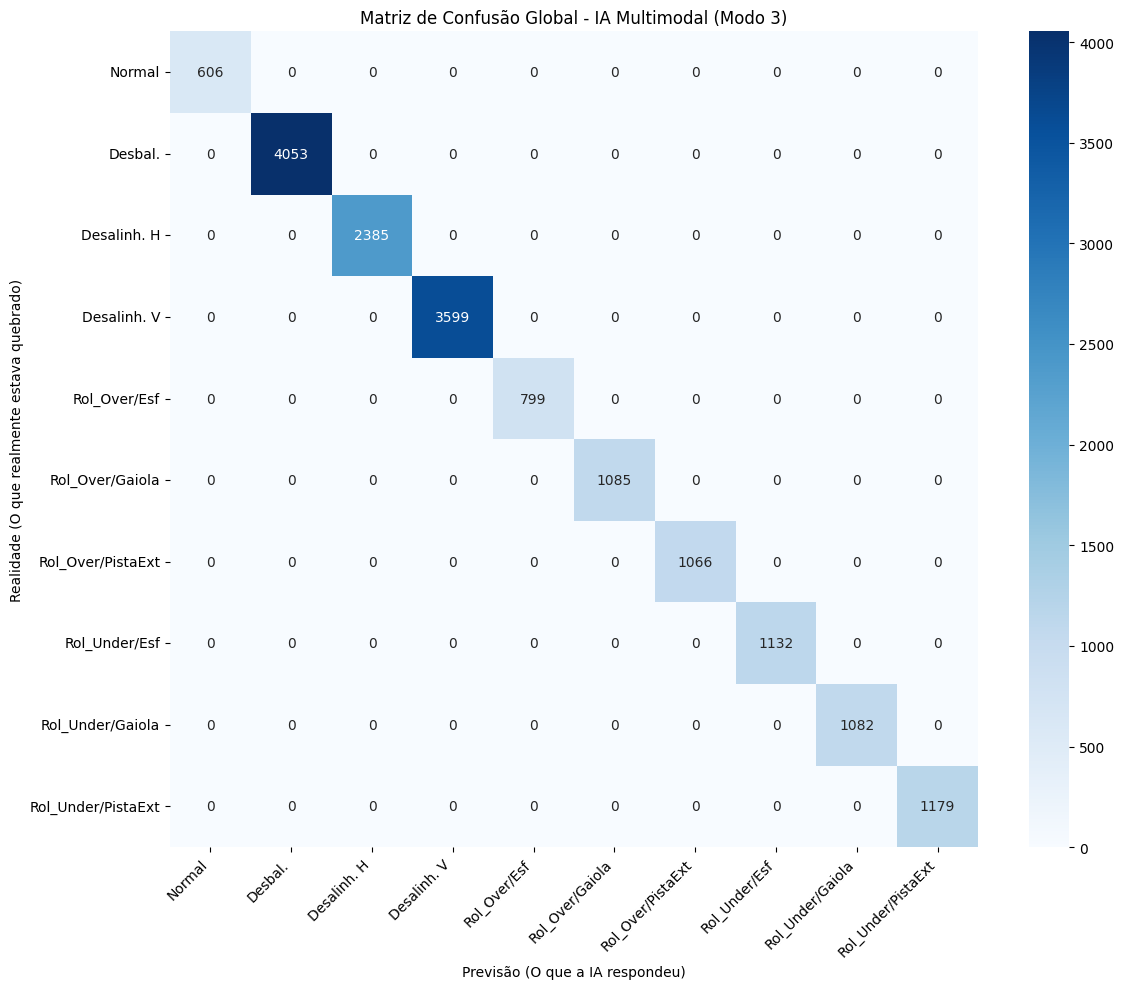


--- RELATÓRIO DE CLASSIFICAÇÃO GLOBAL (MODO 3) ---
                    precision    recall  f1-score   support

            Normal       1.00      1.00      1.00       606
           Desbal.       1.00      1.00      1.00      4053
       Desalinh. H       1.00      1.00      1.00      2385
       Desalinh. V       1.00      1.00      1.00      3599
      Rol_Over/Esf       1.00      1.00      1.00       799
   Rol_Over/Gaiola       1.00      1.00      1.00      1085
 Rol_Over/PistaExt       1.00      1.00      1.00      1066
     Rol_Under/Esf       1.00      1.00      1.00      1132
  Rol_Under/Gaiola       1.00      1.00      1.00      1082
Rol_Under/PistaExt       1.00      1.00      1.00      1179

          accuracy                           1.00     16986
         macro avg       1.00      1.00      1.00     16986
      weighted avg       1.00      1.00      1.00     16986



In [4]:
import os
import glob
import zipfile
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

print("🔎 Iniciando a Auditoria Global do Modelo...")

# Variáveis para acumular os resultados de todos os lotes
y_reais_globais = []
previsoes_classes_globais = []
previsoes_prob_globais = []

pasta_temp = '/content/temp_teste_lote'
pasta_drive_zips = '/content/drive/MyDrive/Dataset_Metrologia_Multimodal'
arquivos_zip = sorted(glob.glob(os.path.join(pasta_drive_zips, '*.zip')))

for lote_idx, arquivo_zip in enumerate(arquivos_zip):
    nome_lote = os.path.basename(arquivo_zip)
    print(f"Testando {nome_lote} ({lote_idx + 1}/{len(arquivos_zip)})...")

    os.makedirs(pasta_temp, exist_ok=True)
    with zipfile.ZipFile(arquivo_zip, 'r') as zip_ref:
        zip_ref.extractall(pasta_temp)

    mascara_lote = df_treino['caminho_imagem'].apply(
        lambda x: os.path.exists(x.replace('/content/temp_imagens', pasta_temp))
    )
    df_lote_atual = df_treino[mascara_lote]

    if len(df_lote_atual) > 0:
        # Pega EXATAMENTE os mesmos 20% que foram usados como Validação no treino
        _, df_local_val = train_test_split(df_lote_atual, test_size=0.2, random_state=42)

        if len(df_local_val) > 0:
            X_tab_val = scaler.transform(df_local_val.drop(columns=[col for col in colunas_texto if col in df_local_val.columns]).values)
            y_val = df_local_val['label_original'].apply(lambda x: 4 if (TIPO_MODELO == 2 and x >= 4) else x).values
            caminhos_val = df_local_val['caminho_imagem'].apply(lambda x: x.replace('/content/temp_imagens', pasta_temp))

            # Cria a esteira apenas para prever
            gerador_local_val = GeradorMultimodal(X_tab_val, caminhos_val, y_val, batch_size=32)

            # Pede para o modelo prever o lote atual sem treinar
            previsoes_prob = modelo_multimodal.predict(gerador_local_val, verbose=0)
            previsoes_classes = np.argmax(previsoes_prob, axis=1)

            # Acumula no caderninho global
            y_reais_globais.extend(y_val)
            previsoes_classes_globais.extend(previsoes_classes)
            previsoes_prob_globais.extend(previsoes_prob)

    shutil.rmtree(pasta_temp)

print("\n✅ Auditoria finalizada! Gerando gráficos de performance...\n")

# =========================================================
# GRÁFICOS E RELATÓRIOS FINAIS
# =========================================================
y_reais_globais = np.array(y_reais_globais)
previsoes_classes_globais = np.array(previsoes_classes_globais)
previsoes_prob_globais = np.array(previsoes_prob_globais)

if TIPO_MODELO == 1:
    nomes_classes = ['Normal', 'Desbalanceamento', 'Desalinh. Horiz.', 'Desalinh. Vert.']
elif TIPO_MODELO == 2:
    nomes_classes = ['Normal', 'Desbalanceamento', 'Desalinh. Horiz.', 'Desalinh. Vert.', 'Falha Rolamento']
else:
    nomes_classes = [
        'Normal', 'Desbal.', 'Desalinh. H', 'Desalinh. V',
        'Rol_Over/Esf', 'Rol_Over/Gaiola', 'Rol_Over/PistaExt',
        'Rol_Under/Esf', 'Rol_Under/Gaiola', 'Rol_Under/PistaExt'
    ]

# 1. MATRIZ DE CONFUSÃO
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_reais_globais, previsoes_classes_globais)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.title(f'Matriz de Confusão Global - IA Multimodal (Modo {TIPO_MODELO})')
plt.ylabel('Realidade (O que realmente estava quebrado)')
plt.xlabel('Previsão (O que a IA respondeu)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. BOLETIM DE NOTAS FINAL
print(f"\n--- RELATÓRIO DE CLASSIFICAÇÃO GLOBAL (MODO {TIPO_MODELO}) ---")
print(classification_report(y_reais_globais, previsoes_classes_globais, target_names=nomes_classes))


Gerando Gráficos Avançados de Performance Global...


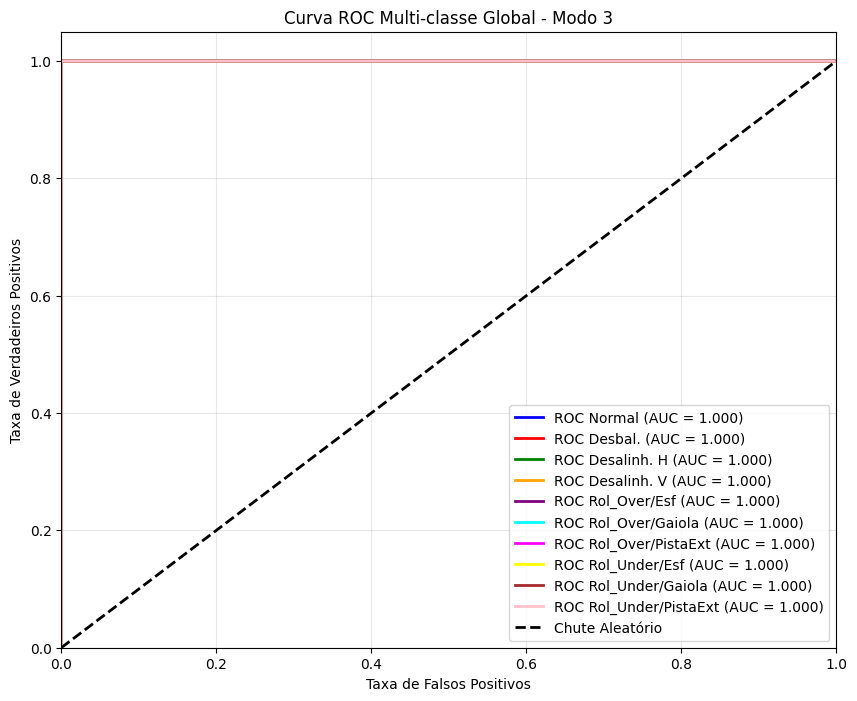

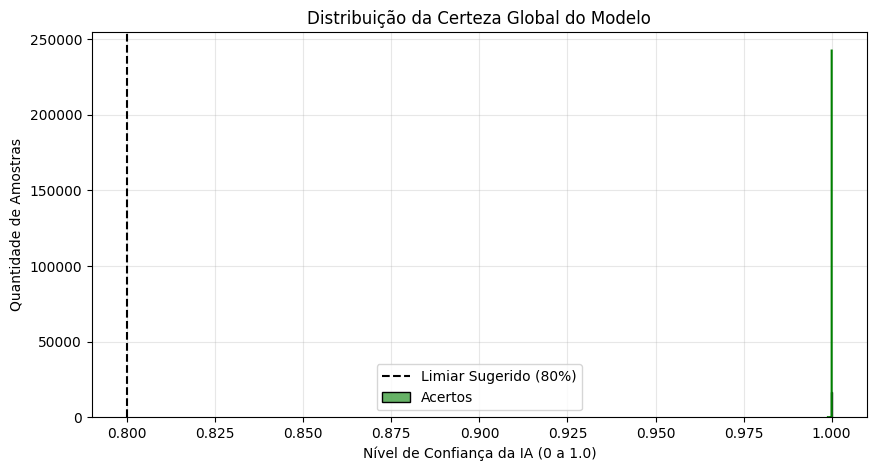


--- INSIGHTS PARA A APLICAÇÃO SAAS ---
Média de confiança geral: 100.00%
Média de confiança quando a IA ERRA: Modelo não cometeu erros nas 138 mil amostras!


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\nGerando Gráficos Avançados de Performance Global...")

# ==========================================================
# GRÁFICO 1: CURVA ROC MULTI-CLASSE GLOBAL
# ==========================================================
# Binariza os labels usando a matriz global real
classes_unicas = np.unique(y_reais_globais)
y_binarizado = label_binarize(y_reais_globais, classes=classes_unicas)
n_classes = y_binarizado.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

# Calcula a curva ROC para cada classe usando as probabilidades globais
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_binarizado[:, i], previsoes_prob_globais[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
cores = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow', 'brown', 'pink'])

for i, color in zip(range(n_classes), cores):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC {nomes_classes[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chute Aleatório')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title(f'Curva ROC Multi-classe Global - Modo {TIPO_MODELO}')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# ==========================================================
# GRÁFICO 2: DISTRIBUIÇÃO DE CONFIANÇA (Certeza da IA)
# ==========================================================
# Pega a probabilidade máxima global (a classe que a IA escolheu)
confiancas = np.max(previsoes_prob_globais, axis=1)

# Separa quem a IA acertou e quem ela errou no escopo global
acertos = previsoes_classes_globais == y_reais_globais
confianca_acertos = confiancas[acertos]
confianca_erros = confiancas[~acertos]

plt.figure(figsize=(10, 5))
sns.histplot(confianca_acertos, bins=20, color='green', kde=True, label='Acertos', alpha=0.6)

# Só plota os erros se o modelo tiver errado alguma coisa!
if len(confianca_erros) > 0:
    sns.histplot(confianca_erros, bins=20, color='red', kde=True, label='Erros', alpha=0.6)

plt.axvline(0.80, color='black', linestyle='--', label='Limiar Sugerido (80%)')
plt.title('Distribuição da Certeza Global do Modelo')
plt.xlabel('Nível de Confiança da IA (0 a 1.0)')
plt.ylabel('Quantidade de Amostras')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ==========================================================
# EXTRA: MÉTRICAS PARA O DASHBOARD (Laravel)
# ==========================================================
print("\n--- INSIGHTS PARA A APLICAÇÃO SAAS ---")
print(f"Média de confiança geral: {np.mean(confiancas)*100:.2f}%")
if len(confianca_erros) > 0:
    print(f"Média de confiança quando a IA ERRA: {np.mean(confianca_erros)*100:.2f}%")
else:
    print("Média de confiança quando a IA ERRA: Modelo não cometeu erros nas 138 mil amostras!")

In [ ]:
from google.colab import files

# Salva o modelo treinado no formato nativo do Keras
modelo.save('modelo_motor.keras')

print("Baixando o Cérebro e a Régua para o seu PC...")

# Baixa os dois arquivos obrigatórios
files.download('modelo_motor.keras')
files.download('scaler_motor.pkl')

Baixando o Cérebro e a Régua para o seu PC...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1. A carregar o Dataset Mestre Embaralhado (Apenas a Tabela)...
A preparar Modelo 3: Especialista (10 Classes)
Formato da Tabela: (84930, 39)

2. A separar e a calibrar a Régua de Normalização...

3. A montar a Rede Neural Tabular (10 Classes)...
Pesos calculados: {0: np.float64(2.8838709677419354), 1: np.float64(0.4254743565658463), 2: np.float64(0.7176930389775008), 3: np.float64(0.46835320879575376), 4: np.float64(2.048356949050347), 5: np.float64(1.515930388219545), 6: np.float64(1.505517394194549), 7: np.float64(1.5264884295663896), 8: np.float64(1.507856191744341), 9: np.float64(1.5526508226691043)}

🚀 A iniciar o Treino do Assistente Tabular...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


133/133 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.6198 - loss: 1.1301 - val_accuracy: 0.7298 - val_loss: 0.8722 - learning_rate: 0.0010
Epoch 2/100
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.7321 - loss: 0.7291 - val_accuracy: 0.7696 - val_loss: 0.6575 - learning_rate: 0.0010
Epoch 3/100
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7574 - loss: 0.6419 - val_accuracy: 0.7885 - val_loss: 0.5644 - learning_rate: 0.0010
Epoch 4/100
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7718 - loss: 0.5884 - val_accuracy: 0.8057 - val_loss: 0.5073 - learning_rate: 0.0010
Epoch 5/100
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7823 - loss: 0.5541 - val_accuracy: 0.8073 - val_loss: 0.4823 - learning_rate: 0.0010
Epoch 6/100
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7915 - loss: 0.5271 - val_accuracy: 0.8196 - val_loss: 0.4466 - learning_rate: 0.0010
Epoch 7/100
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7983 - loss: 0.5019 - 

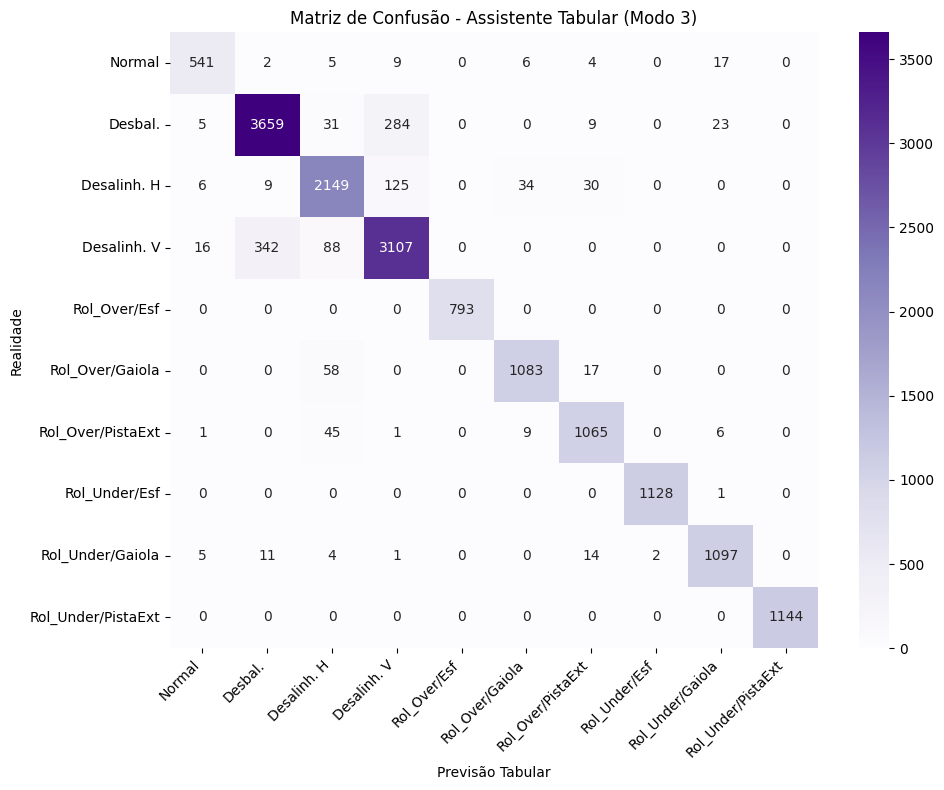


--- RELATÓRIO DO ASSISTENTE TABULAR ---
                    precision    recall  f1-score   support

            Normal       0.94      0.93      0.93       584
           Desbal.       0.91      0.91      0.91      4011
       Desalinh. H       0.90      0.91      0.91      2353
       Desalinh. V       0.88      0.87      0.88      3553
      Rol_Over/Esf       1.00      1.00      1.00       793
   Rol_Over/Gaiola       0.96      0.94      0.95      1158
 Rol_Over/PistaExt       0.94      0.94      0.94      1127
     Rol_Under/Esf       1.00      1.00      1.00      1129
  Rol_Under/Gaiola       0.96      0.97      0.96      1134
Rol_Under/PistaExt       1.00      1.00      1.00      1144

          accuracy                           0.93     16986
         macro avg       0.95      0.95      0.95     16986
      weighted avg       0.93      0.93      0.93     16986



In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

# =========================================================
# 1. PAINEL DE CONTROLO
# =========================================================
TIPO_MODELO = 3 # Escolha 1 (Generalista), 2 (Triador), ou 3 (Especialista)

print("1. A carregar o Dataset Mestre Embaralhado (Apenas a Tabela)...")
df_tabular = pd.read_csv('/content/drive/MyDrive/Dataset_Metrologia_Multimodal/dataset_mestre_embaralhado.csv')

# --- LÓGICA DE TRIAGEM DOS DADOS (Os 3 Modos) ---
if TIPO_MODELO == 1:
    print("A preparar Modelo 1: Generalista (4 Classes)")
    df_treino = df_tabular[df_tabular['label_original'] < 4].copy()
    y = df_treino['label_original'].values
    qtd_classes = 4
    nomes_classes = ['Normal', 'Desbalanceamento', 'Desalinh. Horiz.', 'Desalinh. Vert.']

elif TIPO_MODELO == 2:
    print("A preparar Modelo 2: Triador (5 Classes)")
    df_treino = df_tabular.copy()
    y = df_treino['label_original'].apply(lambda x: 4 if x >= 4 else x).values
    qtd_classes = 5
    nomes_classes = ['Normal', 'Desbalanceamento', 'Desalinh. Horiz.', 'Desalinh. Vert.', 'Falha Rolamento']

else:
    print("A preparar Modelo 3: Especialista (10 Classes)")
    df_treino = df_tabular.copy()
    y = df_treino['label_original'].values
    qtd_classes = 10
    nomes_classes = [
        'Normal', 'Desbal.', 'Desalinh. H', 'Desalinh. V',
        'Rol_Over/Esf', 'Rol_Over/Gaiola', 'Rol_Over/PistaExt',
        'Rol_Under/Esf', 'Rol_Under/Gaiola', 'Rol_Under/PistaExt'
    ]

# Extrai as colunas matemáticas ignorando os textos
colunas_texto = ['label_original', 'arquivo_origem', 'caminho_imagem']
X = df_treino.drop(columns=[col for col in colunas_texto if col in df_treino.columns]).values

print(f"Formato da Tabela: {X.shape}")

# =========================================================
# 2. SEPARAÇÃO E NORMALIZAÇÃO
# =========================================================
print("\n2. A separar e a calibrar a Régua de Normalização...")
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# O Assistente precisa da sua própria régua separada, guardada com o ID do modo
scaler_tabular = StandardScaler()
X_tr_esc = scaler_tabular.fit_transform(X_tr)
X_te_esc = scaler_tabular.transform(X_te)
joblib.dump(scaler_tabular, f'scaler_tabular_mod{TIPO_MODELO}.pkl')

# =========================================================
# 3. O CÉREBRO DO ASSISTENTE (Rede Neural Tabular)
# =========================================================
print(f"\n3. A montar a Rede Neural Tabular ({qtd_classes} Classes)...")
modelo_tabular = Sequential([
    Dense(128, activation='relu', input_shape=(X.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    # A saída adapta-se dinamicamente ao número de classes escolhido
    Dense(qtd_classes, activation='softmax')
])

modelo_tabular.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

# Callbacks para otimizar o tempo e evitar over-fitting
parada_cedo = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
reduzir_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=0.00001, verbose=1)

# =========================================================
# 4. TREINO RELÂMPAGO
# =========================================================
# Calcula o peso ideal para cada uma das 10 classes para equilibrar o jogo
pesos_balanceados = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_tr),
    y=y_tr
)

# Converte para um dicionário que o Keras entende {0: peso, 1: peso...}
dict_pesos = {i: peso for i, peso in enumerate(pesos_balanceados)}

print("Pesos calculados:", dict_pesos)

print("\n🚀 A iniciar o Treino do Assistente Tabular...")
historico = modelo_tabular.fit(
    X_tr_esc, y_tr,
    validation_data=(X_te_esc, y_te),
    epochs=100,
    batch_size=512, # Lote grande pois é apenas matemática leve
    callbacks=[parada_cedo, reduzir_lr],
    verbose=1
)

modelo_tabular.save(f'modelo_tabular_mod{TIPO_MODELO}.keras')
print(f"\n✅ Cérebro do Assistente Tabular (Modo {TIPO_MODELO}) Treinado e Guardado!")

# =========================================================
# 5. AUDITORIA FINAL (Matriz e Gráficos)
# =========================================================
print("\n🔎 A auditar o Assistente...")

# Calcula as previsões na base de teste
previsoes_prob = modelo_tabular.predict(X_te_esc)
previsoes_classes = np.argmax(previsoes_prob, axis=1)

# Matriz de Confusão Roxa para diferenciar visualmente do modelo Multimodal
cm = confusion_matrix(y_te, previsoes_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.title(f'Matriz de Confusão - Assistente Tabular (Modo {TIPO_MODELO})')
plt.ylabel('Realidade')
plt.xlabel('Previsão Tabular')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n--- RELATÓRIO DO ASSISTENTE TABULAR ---")
print(classification_report(y_te, previsoes_classes, target_names=nomes_classes))

1. Carregando o Dataset Mestre Embaralhado...
Preparando XGBoost: Modo Especialista (10 Classes)

2. Separando Dados e Calibrando Scaler...

3. Montando as Árvores de Decisão (10 Classes)...

🚀 Iniciando o Treinamento do XGBoost...
[0]	validation_0-mlogloss:1.96344
[10]	validation_0-mlogloss:0.85312
[20]	validation_0-mlogloss:0.51745
[30]	validation_0-mlogloss:0.36597
[40]	validation_0-mlogloss:0.27907
[50]	validation_0-mlogloss:0.22942
[60]	validation_0-mlogloss:0.19575
[70]	validation_0-mlogloss:0.17285
[80]	validation_0-mlogloss:0.15583
[90]	validation_0-mlogloss:0.14164
[100]	validation_0-mlogloss:0.13048
[110]	validation_0-mlogloss:0.12208
[120]	validation_0-mlogloss:0.11379
[130]	validation_0-mlogloss:0.10711
[140]	validation_0-mlogloss:0.10105
[150]	validation_0-mlogloss:0.09539
[160]	validation_0-mlogloss:0.09056
[170]	validation_0-mlogloss:0.08613
[180]	validation_0-mlogloss:0.08213
[190]	validation_0-mlogloss:0.07875
[200]	validation_0-mlogloss:0.07565
[210]	validation_0-mlog

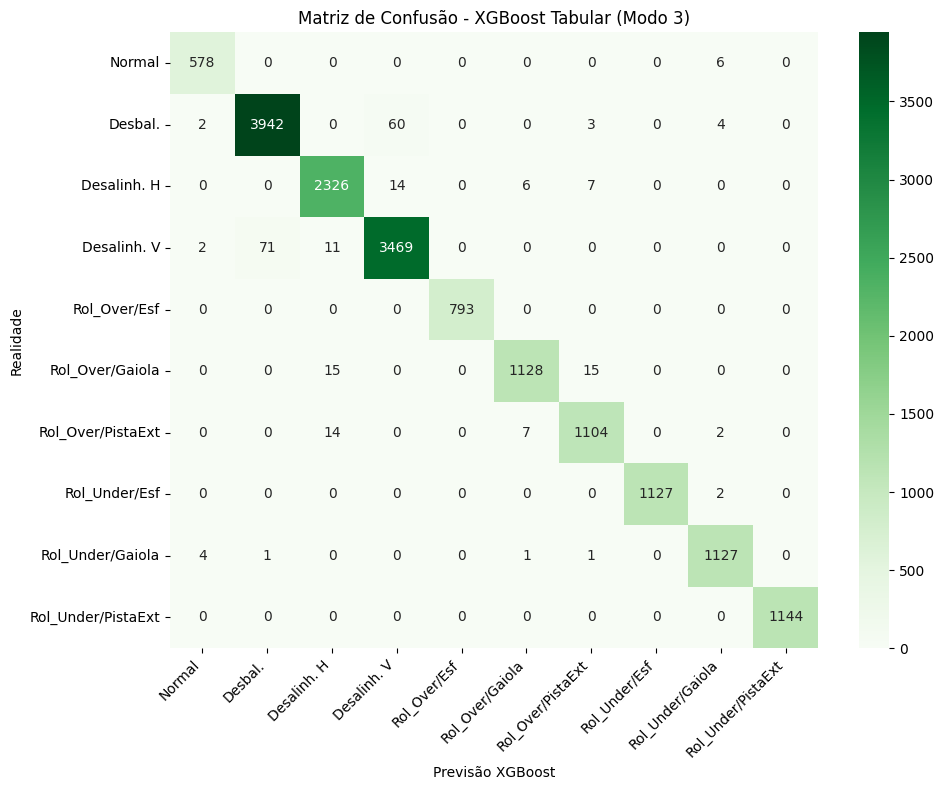


--- RELATÓRIO DO XGBOOST ---
                    precision    recall  f1-score   support

            Normal       0.99      0.99      0.99       584
           Desbal.       0.98      0.98      0.98      4011
       Desalinh. H       0.98      0.99      0.99      2353
       Desalinh. V       0.98      0.98      0.98      3553
      Rol_Over/Esf       1.00      1.00      1.00       793
   Rol_Over/Gaiola       0.99      0.97      0.98      1158
 Rol_Over/PistaExt       0.98      0.98      0.98      1127
     Rol_Under/Esf       1.00      1.00      1.00      1129
  Rol_Under/Gaiola       0.99      0.99      0.99      1134
Rol_Under/PistaExt       1.00      1.00      1.00      1144

          accuracy                           0.99     16986
         macro avg       0.99      0.99      0.99     16986
      weighted avg       0.99      0.99      0.99     16986



In [3]:
import pandas as pd
import numpy as np
import joblib
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1. PAINEL DE CONTROLE
# =========================================================
TIPO_MODELO = 3 # 1 (Generalista), 2 (Triador), ou 3 (Especialista)

print("1. Carregando o Dataset Mestre Embaralhado...")
df_tabular = pd.read_csv('/content/drive/MyDrive/Dataset_Metrologia_Multimodal/dataset_mestre_embaralhado.csv')

if TIPO_MODELO == 1:
    print("Preparando XGBoost: Modo Generalista (4 Classes)")
    df_treino = df_tabular[df_tabular['label_original'] < 4].copy()
    y = df_treino['label_original'].values
    qtd_classes = 4
    nomes_classes = ['Normal', 'Desbalanceamento', 'Desalinh. Horiz.', 'Desalinh. Vert.']
elif TIPO_MODELO == 2:
    print("Preparando XGBoost: Modo Triador (5 Classes)")
    df_treino = df_tabular.copy()
    y = df_treino['label_original'].apply(lambda x: 4 if x >= 4 else x).values
    qtd_classes = 5
    nomes_classes = ['Normal', 'Desbalanceamento', 'Desalinh. Horiz.', 'Desalinh. Vert.', 'Falha Rolamento']
else:
    print("Preparando XGBoost: Modo Especialista (10 Classes)")
    df_treino = df_tabular.copy()
    y = df_treino['label_original'].values
    qtd_classes = 10
    nomes_classes = [
        'Normal', 'Desbal.', 'Desalinh. H', 'Desalinh. V',
        'Rol_Over/Esf', 'Rol_Over/Gaiola', 'Rol_Over/PistaExt',
        'Rol_Under/Esf', 'Rol_Under/Gaiola', 'Rol_Under/PistaExt'
    ]

# Extrai colunas matemáticas
colunas_texto = ['label_original', 'arquivo_origem', 'caminho_imagem']
X = df_treino.drop(columns=[col for col in colunas_texto if col in df_treino.columns]).values

# =========================================================
# 2. SEPARAÇÃO E NORMALIZAÇÃO
# =========================================================
print("\n2. Separando Dados e Calibrando Scaler...")
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_xgb = StandardScaler()
X_tr_esc = scaler_xgb.fit_transform(X_tr)
X_te_esc = scaler_xgb.transform(X_te)
joblib.dump(scaler_xgb, f'scaler_xgboost_mod{TIPO_MODELO}.pkl')

# --- O SEGREDO DO BALANCEAMENTO PARA O XGBOOST ---
# Isso obriga a árvore a prestar muita atenção nas classes minoritárias (ex: Normal)
pesos_amostras = compute_sample_weight(class_weight='balanced', y=y_tr)

# =========================================================
# 3. O CÉREBRO XGBOOST (Árvores de Decisão Gradient Boosting)
# =========================================================
print(f"\n3. Montando as Árvores de Decisão ({qtd_classes} Classes)...")

# Configura o motor do XGBoost
modelo_xgb = xgb.XGBClassifier(
    objective='multi:softprob', # Probabilidade para múltiplas classes
    num_class=qtd_classes,
    n_estimators=300,           # Limite máximo de árvores a serem criadas
    learning_rate=0.1,          # Velocidade de aprendizado
    max_depth=6,                # Profundidade (complexidade) de cada árvore
    early_stopping_rounds=10,   # Se não melhorar em 10 árvores, para!
    random_state=42,
    n_jobs=-1                   # Usa todos os núcleos do processador do Colab
)

# =========================================================
# 4. TREINAMENTO
# =========================================================
print("\n🚀 Iniciando o Treinamento do XGBoost...")
modelo_xgb.fit(
    X_tr_esc, y_tr,
    sample_weight=pesos_amostras, # Aplica o peso para curar o vício!
    eval_set=[(X_te_esc, y_te)],  # Conjunto de prova para o Early Stopping
    verbose=10                    # Mostra o log a cada 10 árvores construídas
)

# Salva no formato nativo do XGBoost
modelo_xgb.save_model(f'modelo_tabular_xgboost_mod{TIPO_MODELO}.json')
print(f"\n✅ XGBoost (Modo {TIPO_MODELO}) Treinado e Salvo!")

# =========================================================
# 5. AUDITORIA FINAL
# =========================================================
print("\n🔎 Auditando o XGBoost...")

previsoes_prob = modelo_xgb.predict_proba(X_te_esc)
previsoes_classes = np.argmax(previsoes_prob, axis=1)

# Matriz de Confusão em Tons de Verde (para diferenciar do Keras)
cm = confusion_matrix(y_te, previsoes_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.title(f'Matriz de Confusão - XGBoost Tabular (Modo {TIPO_MODELO})')
plt.ylabel('Realidade')
plt.xlabel('Previsão XGBoost')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n--- RELATÓRIO DO XGBOOST ---")
print(classification_report(y_te, previsoes_classes, target_names=nomes_classes))


Gerando Gráficos Avançados de Performance (XGBoost)...


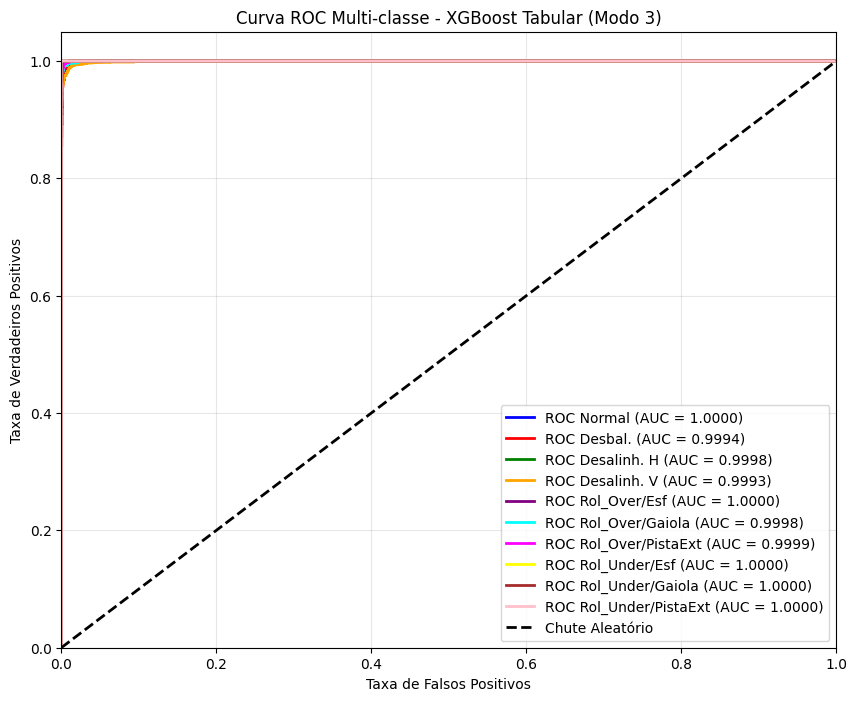

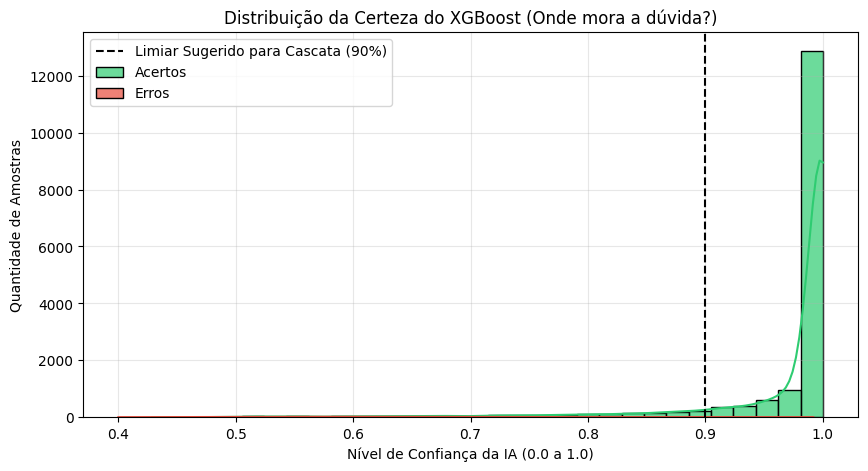


--- INSIGHTS PARA A REGRA DE NEGÓCIO DA API ---
Média de confiança geral (Acertos): 97.13%
Média de confiança quando o XGBoost ERRA: 66.96%
Confiança MÁXIMA de um erro (O pior cenário): 99.18%


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

print("\nGerando Gráficos Avançados de Performance (XGBoost)...")

# ==========================================================
# GRÁFICO 1: CURVA ROC MULTI-CLASSE (XGBOOST)
# ==========================================================
# Binariza os labels reais para calcular a curva ROC
classes_unicas = np.unique(y_te)
y_binarizado = label_binarize(y_te, classes=classes_unicas)
n_classes = len(classes_unicas)

fpr = dict()
tpr = dict()
roc_auc = dict()

# Calcula a curva ROC para cada classe
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_binarizado[:, i], previsoes_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
cores = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow', 'brown', 'pink'])

for i, color in zip(range(n_classes), cores):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC {nomes_classes[i]} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chute Aleatório')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title(f'Curva ROC Multi-classe - XGBoost Tabular (Modo {TIPO_MODELO})')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# ==========================================================
# GRÁFICO 2: DISTRIBUIÇÃO DE CONFIANÇA (O Limiar da Cascata)
# ==========================================================
# Pega a probabilidade máxima (a certeza da árvore de decisão)
confiancas = np.max(previsoes_prob, axis=1)

# Separa acertos e erros
acertos = previsoes_classes == y_te
confianca_acertos = confiancas[acertos]
confianca_erros = confiancas[~acertos]

plt.figure(figsize=(10, 5))
sns.histplot(confianca_acertos, bins=30, color='#2ecc71', kde=True, label='Acertos', alpha=0.7)

# Só plota os erros se o XGBoost tiver errado alguma coisa (o que foi raro!)
if len(confianca_erros) > 0:
    sns.histplot(confianca_erros, bins=30, color='#e74c3c', kde=True, label='Erros', alpha=0.7)

# Linha de sugestão visual (você ajustará isso depois de ver o gráfico)
plt.axvline(0.90, color='black', linestyle='--', label='Limiar Sugerido para Cascata (90%)')

plt.title('Distribuição da Certeza do XGBoost (Onde mora a dúvida?)')
plt.xlabel('Nível de Confiança da IA (0.0 a 1.0)')
plt.ylabel('Quantidade de Amostras')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ==========================================================
# EXTRA: MÉTRICAS ESTRATÉGICAS PARA O BACKEND
# ==========================================================
print("\n--- INSIGHTS PARA A REGRA DE NEGÓCIO DA API ---")
print(f"Média de confiança geral (Acertos): {np.mean(confianca_acertos)*100:.2f}%")
if len(confianca_erros) > 0:
    print(f"Média de confiança quando o XGBoost ERRA: {np.mean(confianca_erros)*100:.2f}%")
    print(f"Confiança MÁXIMA de um erro (O pior cenário): {np.max(confianca_erros)*100:.2f}%")
else:
    print("Média de confiança quando a IA ERRA: Sem erros no lote de teste!")